In [1]:
import pandas as pd
import numpy as np
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import TargetEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn import set_config
set_config(transform_output='pandas') # Do this or else pandas will complain about column being np array

In [2]:
# Use local dataset
train_filepath = "data/titanic_train.csv" 
train_data = pd.read_csv(train_filepath)

test_filepath = "data/titanic_test.csv" 
test_data = pd.read_csv(test_filepath)


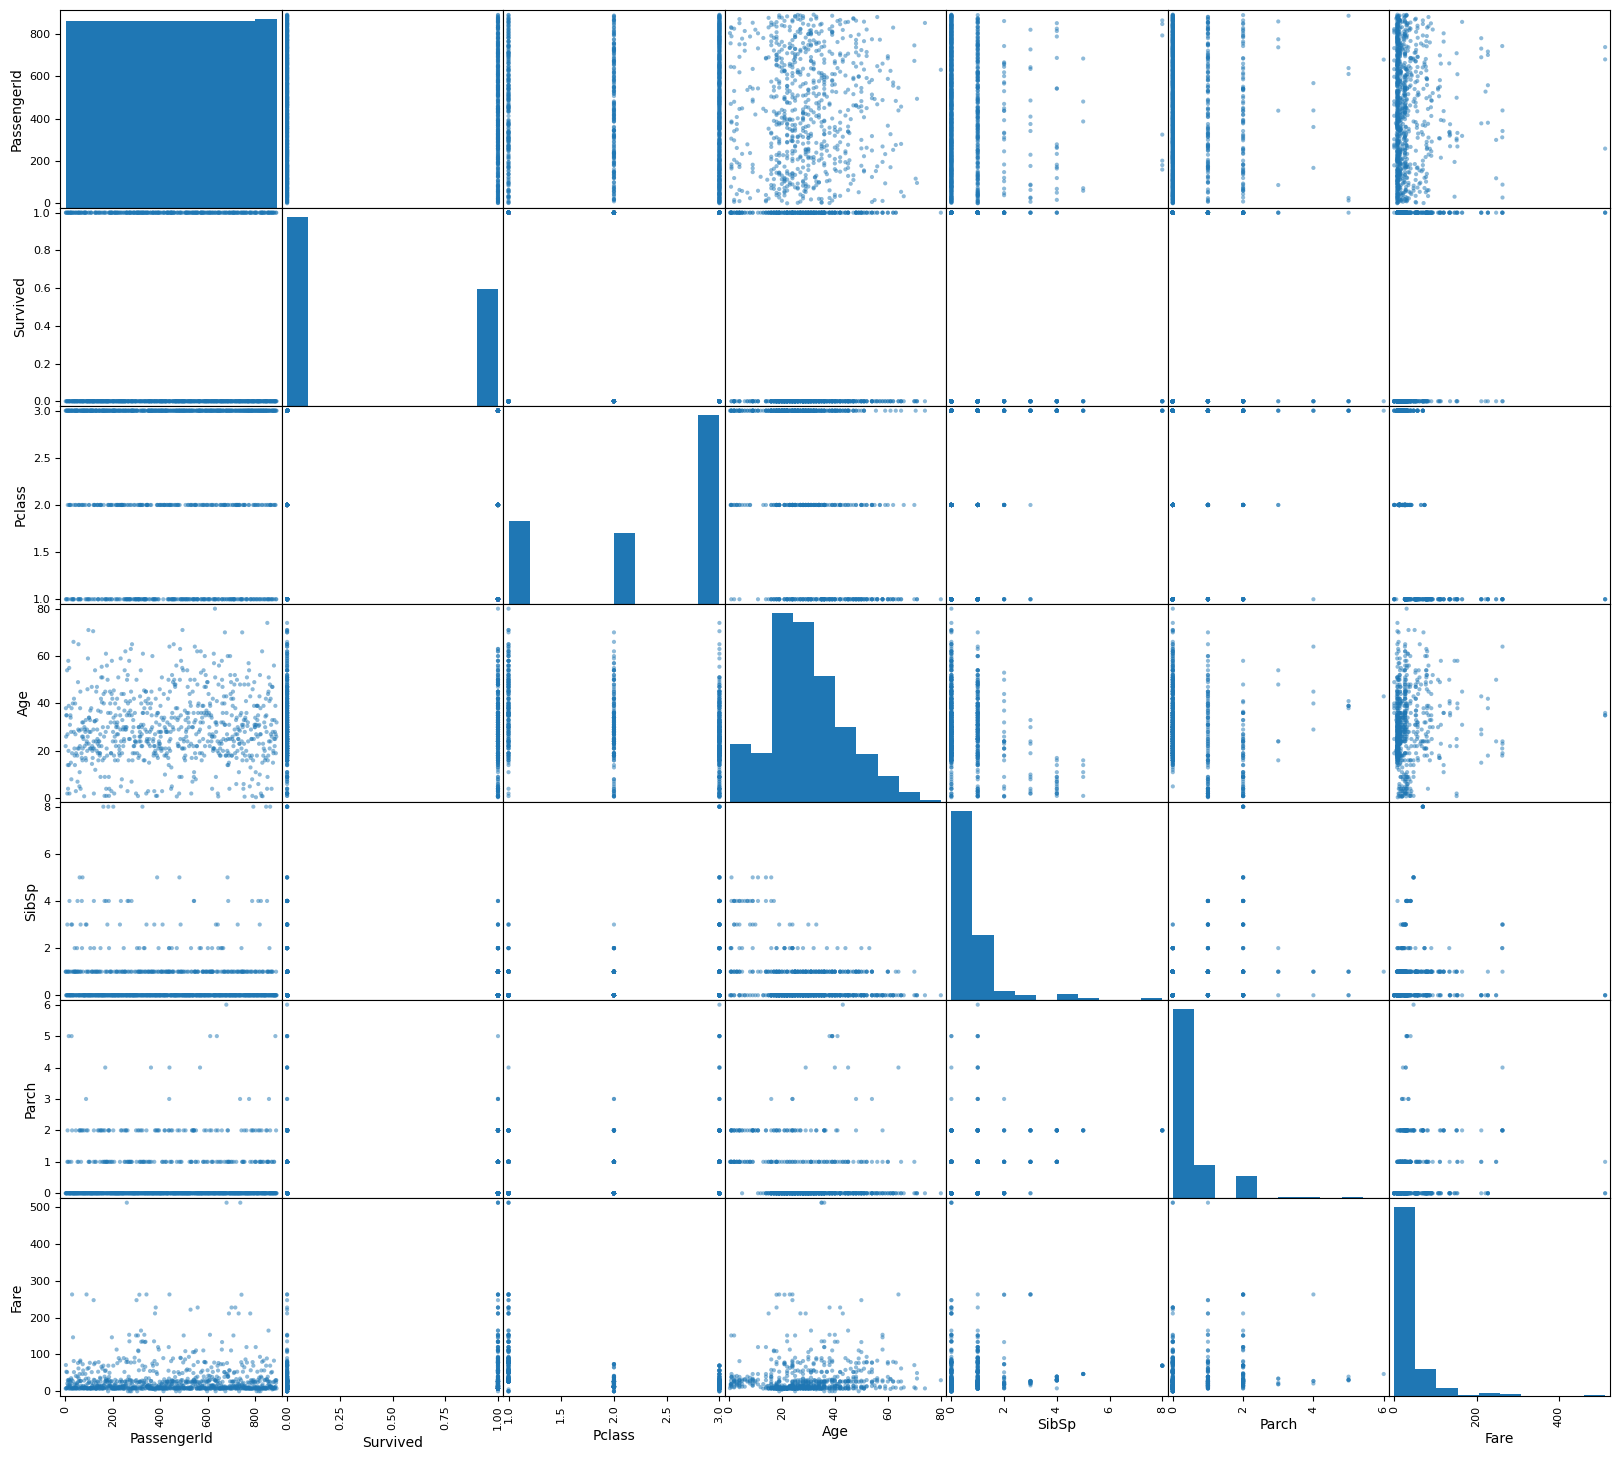

In [3]:
scatter_matrix(train_data,figsize=(20,18))
plt.show()

No relation looks linear nor suitable for neural nets so using RandomForest will be beneficial as it can perform well with clustered train_data

In [4]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Extract the title from name
def clean_name(df):
    name = df['Name']
    temp = name.split(',')[1]
    val = temp.split('.')[0]
    
    return val.strip()

# Append the Title column to both train and test df
train_data['Title'] = train_data.apply(clean_name,axis=1)
test_data['Title'] = test_data.apply(clean_name,axis=1)

In [6]:
# Setting the title of each sample based on their prefix
def title_set(x):
    title = x['Title']

    if title in ['Don', 'Major', 'Capt','Jonkheer','Rev','Col','Sir']:
        return 'Officer'
    elif title in ['Mrs', 'Mme',]:
        return 'Mrs'
    elif title in ['Dona','Lady','the Countess','Master']:
        return "Noble   "
    elif title in ['Mlle','Ms','Miss']:
        return 'Miss'
    elif title == 'Dr':
        if x['Sex'] == 'male':
            return 'Mr'
        else:
            return 'Mrs'
    else:
        return title
    
train_data['Title'] = train_data.apply(title_set,axis=1)
test_data['Title'] = test_data.apply(title_set,axis=1)

In [7]:
# Fill the missing ages and drop Cabin
age_imputer = SimpleImputer(strategy='median')
train_data['Age'] = age_imputer.fit_transform(train_data[['Age']])
test_data['Age'] = age_imputer.fit_transform(test_data[['Age']])
train_data = train_data.drop(['Cabin'],axis= 1)
test_data = test_data.drop('Cabin',axis=1)


In [8]:
# Impute the missing value with mode and mean
train_data['Embarked'] = train_data['Embarked'].fillna(train_data['Embarked'].mode()[0])
test_data['Fare'] = test_data['Fare'].fillna(test_data['Fare'].mean())

In [9]:
# Use Target encoder for features with very high cardinality
target_features = ['Name','Ticket']
target_enc = TargetEncoder(categories="auto",target_type="binary")
train_enc_target_features = target_enc.fit_transform(train_data[['Ticket']],train_data['Survived'])
test_enc_target_features = target_enc.transform(test_data[['Ticket']])
train_data = train_data.drop(target_features,axis=1)
test_data = test_data.drop(target_features,axis=1)

In [10]:
# Use One Hot Encoding for normal categorical values
cat_features = ['Sex','Embarked','Title']
cat_enc = OneHotEncoder(categories="auto",sparse_output=False)
train_enc_cat_features = cat_enc.fit_transform(train_data[cat_features])
test_enc_cata_features = cat_enc.fit_transform(test_data[cat_features])

In [11]:
train_combined_df = pd.concat([train_data,train_enc_cat_features,train_enc_target_features],axis=1)
test_combined_df = pd.concat([test_data,test_enc_cata_features,test_enc_target_features],axis=1)

In [12]:
# Split the train_data into feature columns and labels
X_train = train_combined_df.drop(['Survived','Sex','Embarked','Title'] ,axis=1)
y_train = train_combined_df['Survived']

X_test = test_combined_df.drop(['Sex','Embarked','Title'],axis=1)

In [13]:
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PassengerId     891 non-null    int64  
 1   Pclass          891 non-null    int64  
 2   Age             891 non-null    float64
 3   SibSp           891 non-null    int64  
 4   Parch           891 non-null    int64  
 5   Fare            891 non-null    float64
 6   Sex_female      891 non-null    float64
 7   Sex_male        891 non-null    float64
 8   Embarked_C      891 non-null    float64
 9   Embarked_Q      891 non-null    float64
 10  Embarked_S      891 non-null    float64
 11  Title_Miss      891 non-null    float64
 12  Title_Mr        891 non-null    float64
 13  Title_Mrs       891 non-null    float64
 14  Title_Noble     891 non-null    float64
 15  Title_Officer   891 non-null    float64
 16  Ticket          891 non-null    float64
dtypes: float64(13), int64(4)
memory usage: 118.5 K

In [14]:
# SPlit the train_data to train and validation set
#X_train, X_val, y_train, y_val = train_test_split(X,y,train_size=0.8,random_state=42)

# Tune the hyperparameters to prevent overfitting
model = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    min_samples_leaf=5,
    max_depth=5
    
    )
model.fit(X_train,y_train)
#y_pred = model.predict()

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [15]:
#print(accuracy_score(y_val,y_pred) * 100)

Accuracy is one of the best on the dataset, I can improve it by retaining the relationship among the passengers. TODO: Preserve the relationship among the passengers, which could lead the model to be over 85% accurate.


In [16]:
sub_pred = model.predict(X_test)

In [17]:
submission = pd.DataFrame({
    "PassengerId": test_data["PassengerId"],
    "Survived": sub_pred.astype(int)})

submission.to_csv("gender_submission.csv",index=False)